<a href="https://colab.research.google.com/github/ayushmant908-web/machine_learning-100-Days/blob/main/ridge_regularization_ml_day_54.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from sklearn.datasets import load_diabetes

In [3]:
data=load_diabetes()

In [4]:
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [5]:
X=data.data
y=data.target

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=45)

In [8]:
from sklearn.linear_model import LinearRegression

In [9]:
lr=LinearRegression()

In [10]:
lr.fit(X_train,y_train)

LinearRegression()

In [11]:
print(lr.coef_)
print(lr.intercept_)

[  23.45465406 -247.42747406  492.1087518   329.35876431 -970.79723039
  573.54295519  182.42162368  255.92168168  794.21609282   89.32249214]
152.13623331746496


In [12]:
y_pred=lr.predict(X_test)

In [14]:
from sklearn.metrics import r2_score,mean_squared_error


In [16]:
print('R2_score',r2_score(y_test,y_pred))
print('mse',np.sqrt(mean_squared_error(y_test,y_pred)))

R2_score 0.5188113124539249
mse 48.72713760953253


In [18]:
from sklearn.linear_model import Ridge

In [20]:
r=Ridge(alpha=100000)

In [21]:
r.fit(X_train,y_train)

Ridge(alpha=100000)

In [22]:
print(r.coef_)
print(r.intercept_)

[ 0.00260126  0.00057066  0.00776597  0.0060976   0.00233864  0.00184724
 -0.00513942  0.0052716   0.00734598  0.00528629]
151.83287930791352


In [23]:
y_pred1=r.predict(X_test)

In [26]:
print('r2_score',r2_score(y_test,y_pred1))
print('mse',np.sqrt(mean_squared_error(y_test,y_pred1)))

r2_score -0.00042490200441935855
mse 70.25956272917782


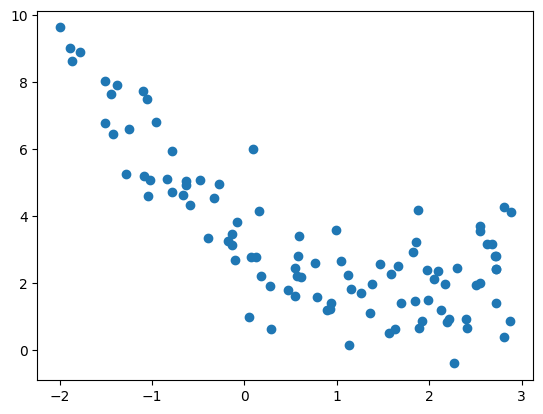

In [31]:
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7 * x1 ** 2 - 2 * x1 + 3 + np.random.randn(m, 1)

plt.scatter(x1, x2)
plt.show()

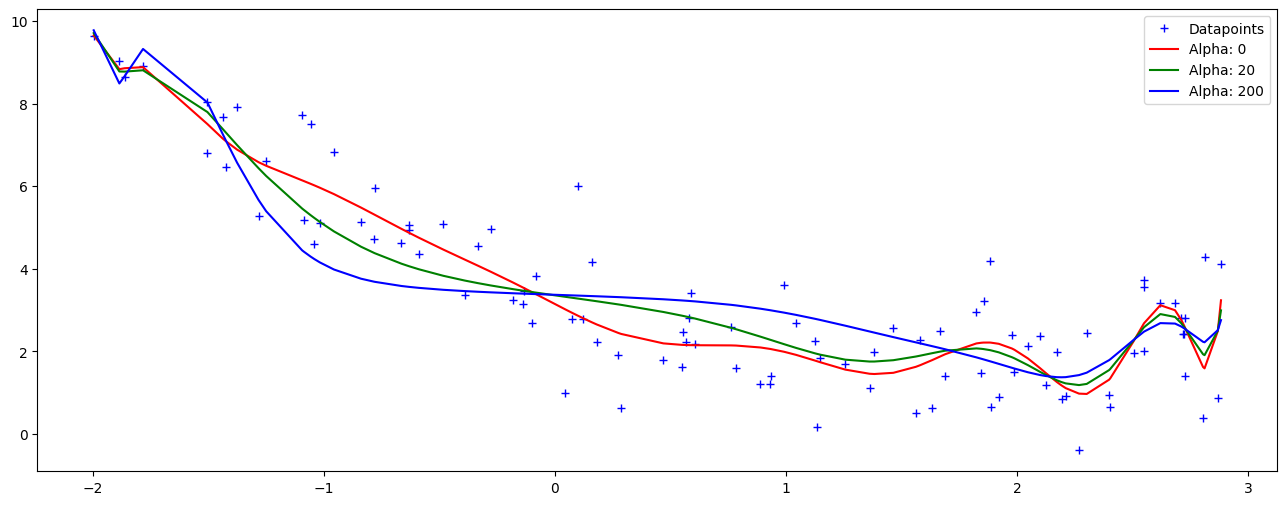

In [54]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

def get_preds_ridge(x1,x2,alpha):

    model=Pipeline([
          ('poly_feat',PolynomialFeatures(degree=16)),
          ('ridge',Ridge(alpha=alpha))
           ])

    model.fit(x1,x2)
    return model.predict(x1)


alphas=[0,20,200]
cs=['r','g','b']

plt.figure(figsize=(16,6))
plt.plot(x1, x2, 'b+', label='Datapoints')

for alpha,c in zip(alphas,cs):
  preds=get_preds_ridge(x1,x2,alpha)

  #plot lines

  plt.plot(sorted(x1[:, 0]), preds[np.argsort(x1[:, 0])], c, label='Alpha: {}'.format(alpha))





plt.legend()
plt.show()
